# 🌬️ Multi-Digital Twin Wind Power Forecasting
## Indian Wind Dataset (SiteID: 36565, Lat: 23.03°N, Lon: 72.56°E)

**Research Paper:** *Research on multi-digital twin and its application in wind power forecasting*

### Pipeline:
1. **Data Loading** → Load Indian wind dataset (8761 hourly records)
2. **Feature Engineering** → Wind shear, temporal encoding, rolling statistics
3. **Wind Power Computation** → P = 0.5 × ρ × A × Cp × v³ (120m wind speed)
4. **Normalization** → MinMaxScaler
5. **Data Split** → 81% Train / 9% Validation / 10% Test
6. **Model Training** → LSTM, GRU, LSTMCNN, GRUCNN
7. **Evaluation** → MAE, RMSE, R², MAPE
8. **MDT Fusion** → Method 1 (Single Metric) & Method 2 (DS Evidence Theory)
9. **Visualization** → 1-Day forecasts, comparison plots

**Window Size = 10 | Using 120m wind speed**


In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)


Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
PyTorch: 2.12.0+cpu
Device: cpu


## 1. Data Loading & Feature Engineering

In [3]:
from data_pipeline import load_indian_dataset, engineer_features, prepare_data, compute_wind_power

# Path to dataset
CSV_PATH = r'36565_23.03_72.56_2014_cc6ea7f2b4966ba2f914d889439754cc.csv'
SAVE_DIR = 'results'
WINDOW_SIZE = 10

# Full pipeline: load → features → normalize → split
train_df, val_df, test_df, scaler, feature_cols, target_col = prepare_data(CSV_PATH, save_dir=SAVE_DIR)

print(f"\nFeature columns ({len(feature_cols)}):")
for i, col in enumerate(feature_cols):
    print(f"  {i+1:2d}. {col}")
print(f"\nTarget: {target_col}")


Dataset size: 8760
Train: 7095 (81.0%)
Val:   788 (9.0%)
Test:  877 (10.0%)
Scaler saved to results\scaler.save

Feature columns (23):
   1. wind_speed_120m
   2. wind_speed_100m
   3. wind_speed_80m
   4. wind_speed_40m
   5. wind_dir_120m
   6. temp_120m
   7. pressure_100m
   8. wind_shear
   9. hour_sin
  10. hour_cos
  11. month_sin
  12. month_cos
  13. temp_gradient
  14. pressure_diff
  15. wind_dir_sin
  16. wind_dir_cos
  17. ws_rolling_mean_6h
  18. ws_rolling_std_6h
  19. ws_rolling_mean_12h
  20. ws_rolling_std_12h
  21. ws_rolling_mean_24h
  22. ws_rolling_std_24h
  23. ws_rate_change

Target: wind_power


## 2. Data Exploration

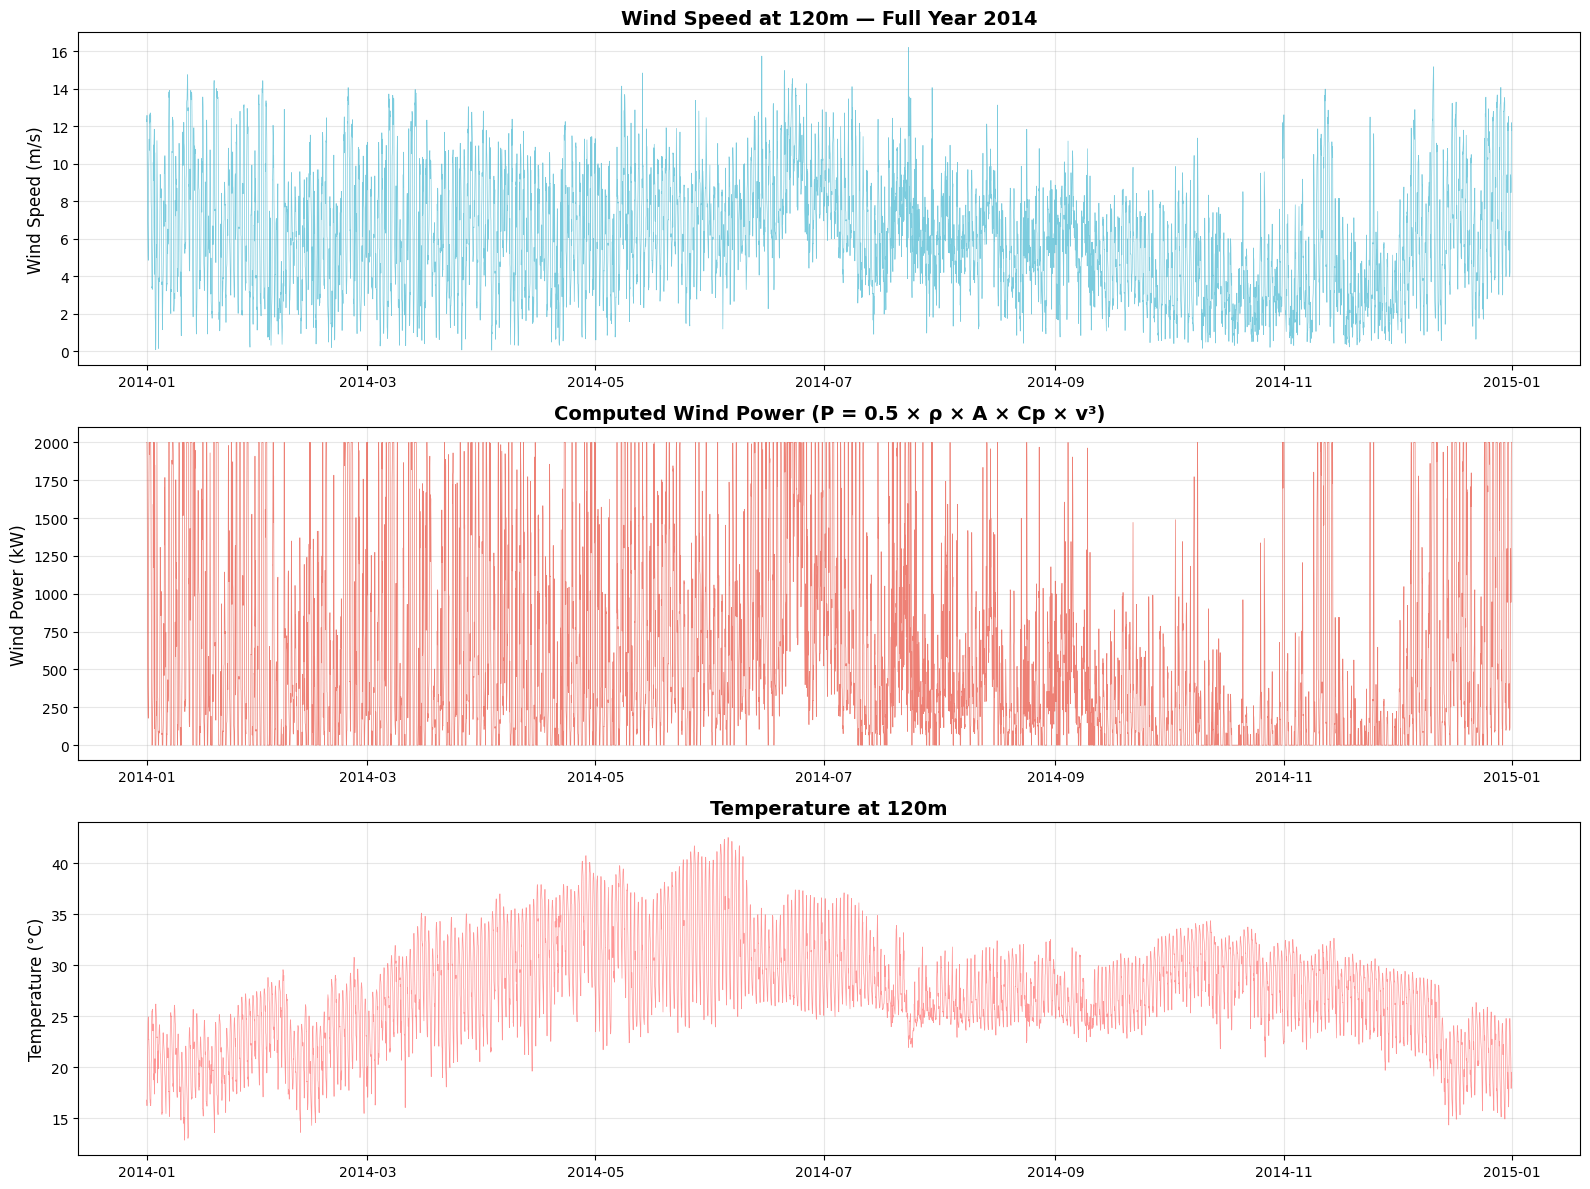


=== Wind Power Statistics (kW) ===
count    8760.000000
mean      572.304777
std       639.718958
min         0.000000
25%        71.513834
50%       316.864046
75%       894.425260
max      2000.000000
Name: wind_power, dtype: float64


In [4]:
# Load raw data for exploration
raw_df = load_indian_dataset(CSV_PATH)
feat_df = engineer_features(raw_df)

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Wind speed at 120m
axes[0].plot(feat_df['datetime'], feat_df['wind_speed_120m'], color='#45B7D1', linewidth=0.5, alpha=0.7)
axes[0].set_ylabel('Wind Speed (m/s)', fontsize=12)
axes[0].set_title('Wind Speed at 120m — Full Year 2014', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Computed wind power
axes[1].plot(feat_df['datetime'], feat_df['wind_power'], color='#E74C3C', linewidth=0.5, alpha=0.7)
axes[1].set_ylabel('Wind Power (kW)', fontsize=12)
axes[1].set_title('Computed Wind Power (P = 0.5 × ρ × A × Cp × v³)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Temperature at 120m
axes[2].plot(feat_df['datetime'], feat_df['temp_120m'], color='#FF6B6B', linewidth=0.5, alpha=0.7)
axes[2].set_ylabel('Temperature (°C)', fontsize=12)
axes[2].set_title('Temperature at 120m', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print("\n=== Wind Power Statistics (kW) ===")
print(feat_df['wind_power'].describe())


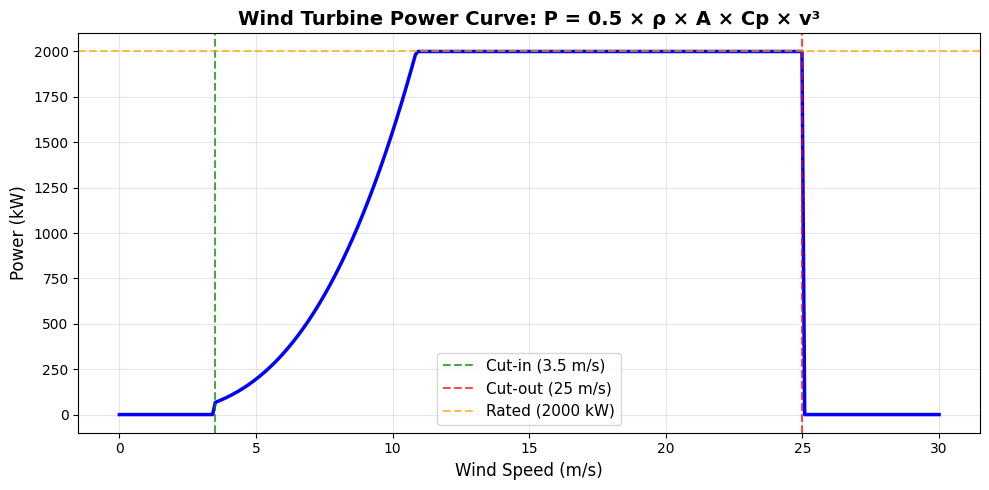

In [5]:
# Visualize the power curve
speeds = np.linspace(0, 30, 300)
power = compute_wind_power(speeds)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(speeds, power, 'b-', linewidth=2.5)
ax.axvline(x=3.5, color='g', linestyle='--', alpha=0.7, label='Cut-in (3.5 m/s)')
ax.axvline(x=25.0, color='r', linestyle='--', alpha=0.7, label='Cut-out (25 m/s)')
ax.axhline(y=2000, color='orange', linestyle='--', alpha=0.7, label='Rated (2000 kW)')
ax.set_xlabel('Wind Speed (m/s)', fontsize=12)
ax.set_ylabel('Power (kW)', fontsize=12)
ax.set_title('Wind Turbine Power Curve: P = 0.5 × ρ × A × Cp × v³', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


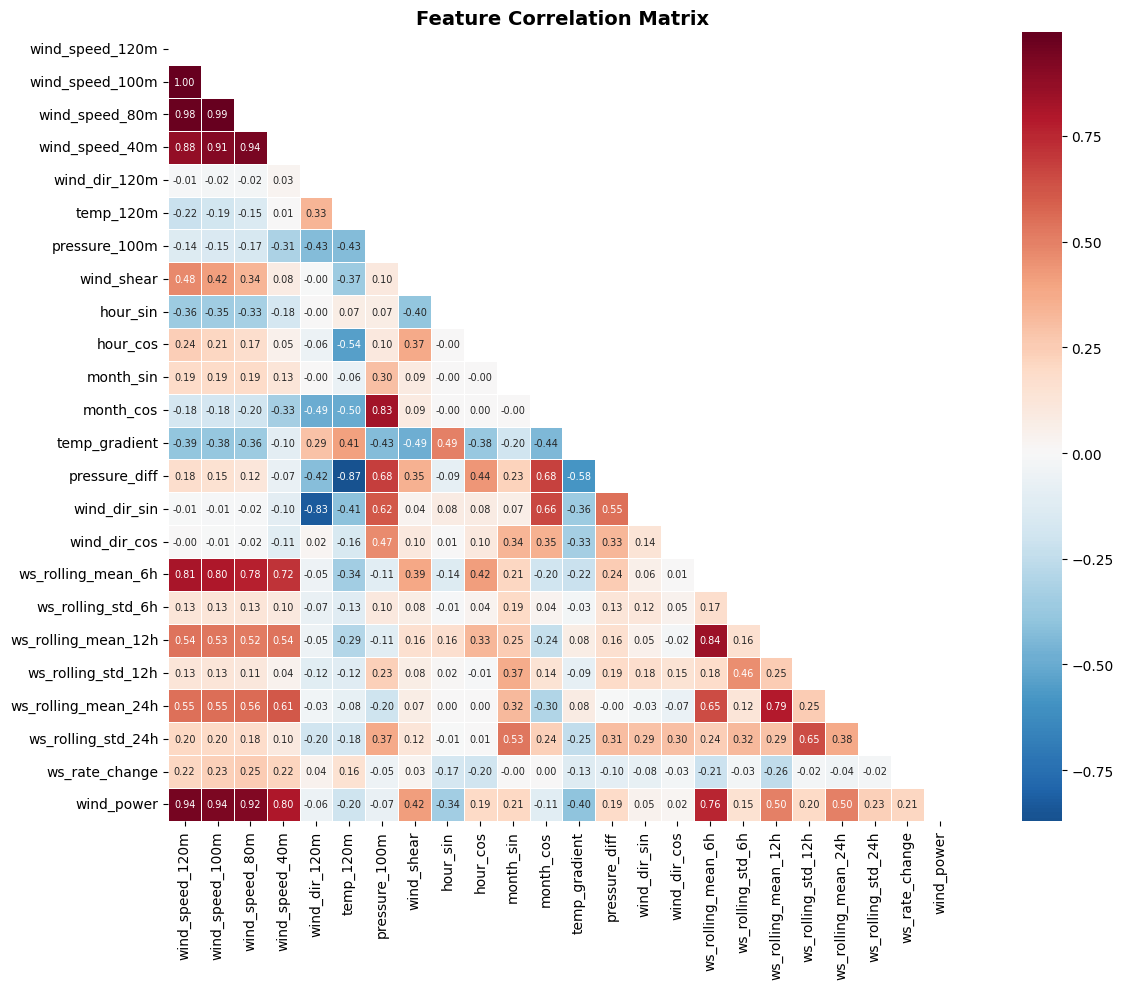

In [6]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr = feat_df.drop(columns=['datetime']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
           ax=ax, square=True, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Model Training

Training 4 models: **LSTM, GRU, LSTMCNN, GRUCNN**
- Batch size: 64
- Learning rate: 0.01
- Optimizer: Adam
- Early stopping: patience=10
- Window size: 10


In [7]:
from train import train_all_models

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

results = train_all_models(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    feature_cols=feature_cols,
    target_col=target_col,
    window_size=WINDOW_SIZE,
    batch_size=64,
    lr=0.01,
    epochs=100,
    patience=10,
    save_dir=SAVE_DIR,
    device=DEVICE
)

print("\n✅ All models trained successfully!")



Training LSTM
  Input size: 23, Window: 10
  Train samples: 7085, Val samples: 778
  Batch size: 64, LR: 0.01, Max epochs: 100
  Epoch  10/100 | Train Loss: 0.019990 | Val Loss: 0.009978 | Best: 0.008571 | Patience: 5/10
  Epoch  20/100 | Train Loss: 0.017736 | Val Loss: 0.009698 | Best: 0.008201 | Patience: 3/10
  Epoch  30/100 | Train Loss: 0.017076 | Val Loss: 0.010697 | Best: 0.007928 | Patience: 6/10
  Epoch  34/100 | Train Loss: 0.016343 | Val Loss: 0.011366 | Best: 0.007928 | Patience: 10/10
  Early stopping at epoch 34
  Best model saved to results\models\LSTM_best.pth
  Test predictions saved: 867 samples

Training GRU
  Input size: 23, Window: 10
  Train samples: 7085, Val samples: 778
  Batch size: 64, LR: 0.01, Max epochs: 100
  Epoch  10/100 | Train Loss: 0.019222 | Val Loss: 0.010159 | Best: 0.009337 | Patience: 4/10
  Epoch  20/100 | Train Loss: 0.018552 | Val Loss: 0.010106 | Best: 0.008761 | Patience: 2/10
  Epoch  30/100 | Train Loss: 0.017298 | Val Loss: 0.009713 | 

## 4. Training Loss Curves

In [8]:
from visualize import plot_training_loss

plot_training_loss(results, save_path='results/plots/training_loss.png')

# Also show inline
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training & Validation Loss Curves', fontsize=16, fontweight='bold')
colors = {'LSTM': '#FF6B6B', 'GRU': '#4ECDC4', 'LSTMCNN': '#45B7D1', 'GRUCNN': '#96CEB4'}

for ax, (name, data) in zip(axes.flatten(), results.items()):
    ax.plot(data['train_losses'], label='Train', color=colors[name], alpha=0.8)
    ax.plot(data['val_losses'], label='Validation', color='orange', alpha=0.8)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Single Digital Twin Evaluation Metrics

Evaluation on **test set** (10% of data):
- **MAE** — Mean Absolute Error
- **RMSE** — Root Mean Squared Error  
- **R²** — Coefficient of Determination
- **MAPE** — Mean Absolute Percentage Error


In [9]:
from evaluate import compute_all_metrics, metrics_to_table

single_metrics = compute_all_metrics(results, print_results=True)

# Display as table
metrics_table = metrics_to_table(single_metrics)
print("\n" + "="*60)
print("  SINGLE DIGITAL TWIN — TEST SET METRICS")
print("="*60)
print(metrics_table.to_string())
print()



────────────────────────────────────────
  LSTM Evaluation Metrics
────────────────────────────────────────
     MAE: 0.074
    RMSE: 0.1248
      R2: 0.8809
    MAPE: 40.6315

────────────────────────────────────────
  GRU Evaluation Metrics
────────────────────────────────────────
     MAE: 0.074
    RMSE: 0.1197
      R2: 0.8904
    MAPE: 40.9482

────────────────────────────────────────
  LSTMCNN Evaluation Metrics
────────────────────────────────────────
     MAE: 0.1367
    RMSE: 0.1837
      R2: 0.7417
    MAPE: 68.1756

────────────────────────────────────────
  GRUCNN Evaluation Metrics
────────────────────────────────────────
     MAE: 0.1172
    RMSE: 0.1696
      R2: 0.78
    MAPE: 60.0517

  SINGLE DIGITAL TWIN — TEST SET METRICS
            MAE    RMSE      R2     MAPE
Model                                   
LSTM     0.0740  0.1248  0.8809  40.6315
GRU      0.0740  0.1197  0.8904  40.9482
LSTMCNN  0.1367  0.1837  0.7417  68.1756
GRUCNN   0.1172  0.1696  0.7800  60.0517


## 6. 1-Day Forecast Visualization

Showing actual vs predicted wind power for each model over a single day (24 hours).


In [10]:
from data_pipeline import inverse_transform_target

# Pick a day from the test set (e.g., starting at index 0, 24, 48, etc.)
day_starts = [0, 48, 96]  # Show 3 different days

for day_idx, start in enumerate(day_starts):
    fig, ax = plt.subplots(figsize=(16, 5))
    
    actual_raw = results['LSTM']['test_actual'][start:start+24]
    actual_kw = inverse_transform_target(scaler, actual_raw, feature_cols, target_col)
    hours = np.arange(24)
    
    ax.plot(hours, actual_kw, 'ko-', linewidth=2.5, markersize=6, label='Actual', zorder=5)
    
    colors_list = {'LSTM': '#FF6B6B', 'GRU': '#4ECDC4', 'LSTMCNN': '#45B7D1', 'GRUCNN': '#96CEB4'}
    for name, data in results.items():
        pred_raw = data['test_pred'][start:start+24]
        pred_kw = inverse_transform_target(scaler, pred_raw, feature_cols, target_col)
        ax.plot(hours, pred_kw, '--', color=colors_list[name], linewidth=1.8, alpha=0.85, label=name)
    
    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Wind Power (kW)', fontsize=12)
    ax.set_title(f'Day {day_idx+1} — Wind Power Forecast Comparison', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(hours)
    plt.tight_layout()
    plt.savefig(f'results/plots/day_{day_idx+1}_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()


In [11]:
from visualize import plot_scatter

plot_scatter(results, scaler, feature_cols, target_col, save_path='results/plots/scatter.png')

# Show inline
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Actual vs Predicted (Scatter)', fontsize=16, fontweight='bold')
colors_list = {'LSTM': '#FF6B6B', 'GRU': '#4ECDC4', 'LSTMCNN': '#45B7D1', 'GRUCNN': '#96CEB4'}

for ax, (name, data) in zip(axes.flatten(), results.items()):
    actual = inverse_transform_target(scaler, data['test_actual'], feature_cols, target_col)
    pred = inverse_transform_target(scaler, data['test_pred'], feature_cols, target_col)
    
    ax.scatter(actual, pred, alpha=0.3, s=10, color=colors_list[name])
    lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, alpha=0.7, label='Perfect')
    ax.set_xlabel('Actual (kW)')
    ax.set_ylabel('Predicted (kW)')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/scatter_inline.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Multi-Digital Twin Fusion Methods

### Method 1: Single Metric Dynamic Preference (Time Window)
- Selects the best model (lowest RMSE) in each sliding window
- Window size = 10

### Method 2: Multi-Metrics Dynamic Fusion (DS Evidence Theory)
- Combines RMSE, MAE, R² using Dempster-Shafer evidence theory
- Threshold ζ = 0.03
- Window size = 10

Tests all combinations: 2-DT, 3-DT, and 4-DT


In [12]:
from fusion import run_all_fusion

# Prepare predictions dict
predictions_dict = {name: data['test_pred'] for name, data in results.items()}
actuals = results['LSTM']['test_actual']  # Same actuals for all

fusion_results = run_all_fusion(
    predictions_dict,
    actuals,
    window_size=WINDOW_SIZE,
    zeta=0.03,
    print_results=True
)

print("\n✅ Fusion analysis complete!")



  Combination: LSTM&GRU

────────────────────────────────────────
  Method 1 (LSTM&GRU) Evaluation Metrics
────────────────────────────────────────
     MAE: 0.0722
    RMSE: 0.1222
      R2: 0.886
    MAPE: 38.3365

────────────────────────────────────────
  Method 2 (LSTM&GRU) Evaluation Metrics
────────────────────────────────────────
     MAE: 0.0714
    RMSE: 0.1212
      R2: 0.8878
    MAPE: 37.9092

  Combination: LSTM&LSTMCNN

────────────────────────────────────────
  Method 1 (LSTM&LSTMCNN) Evaluation Metrics
────────────────────────────────────────
     MAE: 0.083
    RMSE: 0.1358
      R2: 0.8592
    MAPE: 43.4925

────────────────────────────────────────
  Method 2 (LSTM&LSTMCNN) Evaluation Metrics
────────────────────────────────────────
     MAE: 0.0813
    RMSE: 0.1324
      R2: 0.8662
    MAPE: 41.9105

  Combination: LSTM&GRUCNN

────────────────────────────────────────
  Method 1 (LSTM&GRUCNN) Evaluation Metrics
────────────────────────────────────────
     MAE: 0.0

## 8. Results Summary Tables

In [13]:
# Method 1 Results Table
m1_df = pd.DataFrame(fusion_results['method1']).T
m1_df.index.name = 'Combination'
print("="*70)
print("  METHOD 1: Single Metric Dynamic Preference (RMSE-based)")
print("="*70)
print(m1_df.to_string())

print()

# Method 2 Results Table
m2_df = pd.DataFrame(fusion_results['method2']).T
m2_df.index.name = 'Combination'
print("="*70)
print("  METHOD 2: Multi-Metrics Dynamic Fusion (DS Evidence Theory)")
print("="*70)
print(m2_df.to_string())

# Best results
print("\n" + "="*70)
print("  BEST RESULTS SUMMARY")
print("="*70)
best_single = min(single_metrics, key=lambda k: single_metrics[k]['MAE'])
best_m1 = min(fusion_results['method1'], key=lambda k: fusion_results['method1'][k]['MAE'])
best_m2 = min(fusion_results['method2'], key=lambda k: fusion_results['method2'][k]['MAE'])

print(f"  Best Single DT: {best_single} → MAE={single_metrics[best_single]['MAE']}, RMSE={single_metrics[best_single]['RMSE']}, R²={single_metrics[best_single]['R2']}")
print(f"  Best Method 1:  {best_m1} → MAE={fusion_results['method1'][best_m1]['MAE']}, RMSE={fusion_results['method1'][best_m1]['RMSE']}, R²={fusion_results['method1'][best_m1]['R2']}")
print(f"  Best Method 2:  {best_m2} → MAE={fusion_results['method2'][best_m2]['MAE']}, RMSE={fusion_results['method2'][best_m2]['RMSE']}, R²={fusion_results['method2'][best_m2]['R2']}")


  METHOD 1: Single Metric Dynamic Preference (RMSE-based)
                            MAE    RMSE      R2     MAPE
Combination                                             
LSTM&GRU                 0.0722  0.1222  0.8860  38.3365
LSTM&LSTMCNN             0.0830  0.1358  0.8592  43.4925
LSTM&GRUCNN              0.0809  0.1333  0.8643  42.2405
GRU&LSTMCNN              0.0823  0.1296  0.8718  43.0013
GRU&GRUCNN               0.0806  0.1273  0.8763  42.0988
LSTMCNN&GRUCNN           0.1194  0.1698  0.7801  59.1839
LSTM&GRU&LSTMCNN         0.0789  0.1296  0.8718  40.4522
LSTM&GRU&GRUCNN          0.0773  0.1274  0.8760  39.2645
LSTM&LSTMCNN&GRUCNN      0.0828  0.1346  0.8618  43.1903
GRU&LSTMCNN&GRUCNN       0.0821  0.1274  0.8761  42.5990
LSTM&GRU&LSTMCNN&GRUCNN  0.0781  0.1267  0.8774  39.6558

  METHOD 2: Multi-Metrics Dynamic Fusion (DS Evidence Theory)
                            MAE    RMSE      R2     MAPE
Combination                                             
LSTM&GRU                

In [14]:
from visualize import plot_metrics_comparison

plot_metrics_comparison(
    single_metrics,
    fusion_results['method1'],
    fusion_results['method2'],
    save_path='results/plots/metrics_comparison.png'
)

# Show inline bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Evaluation Metrics: Single DT vs Best Fusion', fontsize=16, fontweight='bold')

all_models = {}
for k, v in single_metrics.items():
    all_models[k] = v
all_models[f'M1:{best_m1}'] = fusion_results['method1'][best_m1]
all_models[f'M2:{best_m2}'] = fusion_results['method2'][best_m2]

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    names = list(all_models.keys())
    vals = [all_models[n][metric] for n in names]
    colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#E74C3C', '#3498DB'][:len(names)]
    
    bars = ax.bar(range(len(names)), vals, color=colors_bar, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
               f'{v:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('results/plots/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🎉 All results saved to results/ directory!")



🎉 All results saved to results/ directory!


## 9. Save All Results

In [15]:
# Save single model metrics
single_df = metrics_to_table(single_metrics)
single_df.to_csv('results/single_dt_metrics.csv')

# Save fusion results
m1_df.to_csv('results/method1_fusion_metrics.csv')
m2_df.to_csv('results/method2_fusion_metrics.csv')

# Save predictions for each model
for name, data in results.items():
    pred_df = pd.DataFrame({
        'prediction': data['test_pred'],
        'actual': data['test_actual']
    })
    pred_df.to_csv(f'results/predictions/{name}_predictions.csv', index=False)

print("✅ All results saved!")
print("\nFiles saved:")
for root, dirs, files in os.walk('results'):
    for f in files:
        print(f"  {os.path.join(root, f)}")


✅ All results saved!

Files saved:
  results\method1_fusion_metrics.csv
  results\method2_fusion_metrics.csv
  results\scaler.save
  results\single_dt_metrics.csv
  results\models\GRUCNN_best.pth
  results\models\GRU_best.pth
  results\models\LSTMCNN_best.pth
  results\models\LSTM_best.pth
  results\plots\day_1_forecast.png
  results\plots\day_2_forecast.png
  results\plots\day_3_forecast.png
  results\plots\final_comparison.png
  results\plots\metrics_comparison.png
  results\plots\scatter.png
  results\plots\scatter_inline.png
  results\plots\training_loss.png
  results\predictions\GRUCNN_predictions.csv
  results\predictions\GRU_predictions.csv
  results\predictions\LSTMCNN_predictions.csv
  results\predictions\LSTM_predictions.csv
